# 第十三章：Transformer - 注意力就是你所需要的

## Attention Is All You Need (Vaswani et al., 2017)

這篇論文提出了革命性的 Transformer 架構，完全捨棄循環結構，僅用注意力機制處理序列資料。

**核心貢獻**：
- 縮放點積注意力（Scaled Dot-Product Attention）
- 多頭注意力（Multi-Head Attention）
- 位置編碼（Positional Encoding）
- 完全可平行化的架構

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

# 設定隨機種子
torch.manual_seed(42)
np.random.seed(42)

# 檢查裝置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用裝置：{device}")

使用裝置：cpu


## 1. 縮放點積注意力

注意力機制的核心公式：

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

- **Q (Query)**：查詢向量，代表「我在找什麼」
- **K (Key)**：鍵向量，代表「我有什麼」
- **V (Value)**：值向量，代表「實際內容」
- **$\sqrt{d_k}$**：縮放因子，防止點積過大導致梯度消失

In [2]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    縮放點積注意力
    
    Args:
        Q: 查詢矩陣 [batch, heads, seq_len, d_k]
        K: 鍵矩陣 [batch, heads, seq_len, d_k]
        V: 值矩陣 [batch, heads, seq_len, d_v]
        mask: 可選的遮罩
    
    Returns:
        output: 注意力輸出
        attention_weights: 注意力權重
    """
    d_k = Q.shape[-1]
    
    # 計算注意力分數：QK^T / sqrt(d_k)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    
    # 套用遮罩（如果有的話）
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))
    
    # Softmax 得到注意力權重
    attention_weights = F.softmax(scores, dim=-1)
    
    # 加權求和
    output = torch.matmul(attention_weights, V)
    
    return output, attention_weights

# 測試縮放點積注意力
batch_size = 2
num_heads = 1
seq_len = 4
d_k = 8

Q = torch.randn(batch_size, num_heads, seq_len, d_k)
K = torch.randn(batch_size, num_heads, seq_len, d_k)
V = torch.randn(batch_size, num_heads, seq_len, d_k)

output, attn_weights = scaled_dot_product_attention(Q, K, V)

print("縮放點積注意力測試：")
print(f"  輸入形狀 Q: {Q.shape}")
print(f"  輸入形狀 K: {K.shape}")
print(f"  輸入形狀 V: {V.shape}")
print(f"  輸出形狀: {output.shape}")
print(f"  注意力權重形狀: {attn_weights.shape}")
print(f"  注意力權重和（應為 1）: {attn_weights[0, 0].sum(dim=-1)}")

縮放點積注意力測試：
  輸入形狀 Q: torch.Size([2, 1, 4, 8])
  輸入形狀 K: torch.Size([2, 1, 4, 8])
  輸入形狀 V: torch.Size([2, 1, 4, 8])
  輸出形狀: torch.Size([2, 1, 4, 8])
  注意力權重形狀: torch.Size([2, 1, 4, 4])
  注意力權重和（應為 1）: tensor([1.0000, 1.0000, 1.0000, 1.0000])


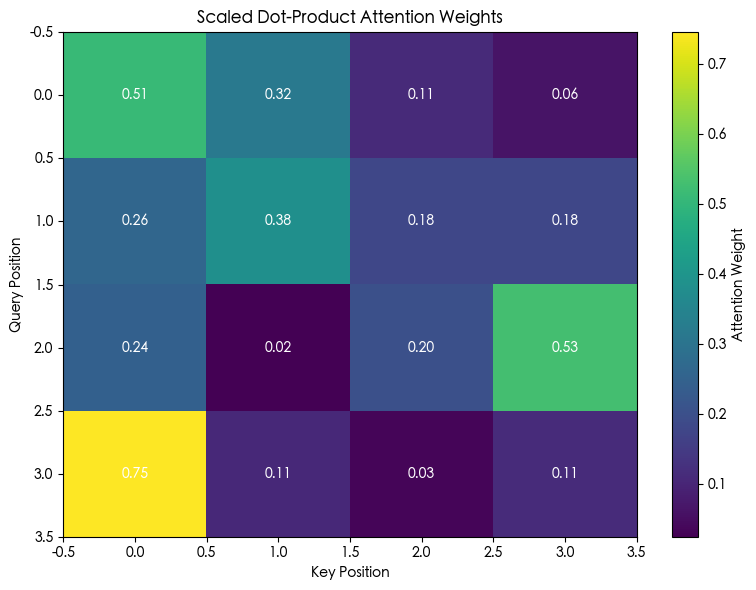

圖片已儲存：attention_weights.png


In [3]:
# 視覺化注意力權重
fig, ax = plt.subplots(figsize=(8, 6))

# 取第一個批次、第一個頭的注意力權重
weights = attn_weights[0, 0].detach().numpy()

im = ax.imshow(weights, cmap='viridis', aspect='auto')
plt.colorbar(im, label='Attention Weight')
ax.set_xlabel('Key Position')
ax.set_ylabel('Query Position')
ax.set_title('Scaled Dot-Product Attention Weights')

# 加入數值標註
for i in range(weights.shape[0]):
    for j in range(weights.shape[1]):
        ax.text(j, i, f'{weights[i, j]:.2f}', ha='center', va='center', color='white')

plt.tight_layout()
plt.savefig('attention_weights.png', dpi=150, bbox_inches='tight')
plt.show()

print("圖片已儲存：attention_weights.png")

## 2. 多頭注意力

多頭注意力讓模型能同時關注不同的表示子空間：

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, ..., \text{head}_h)W^O$$

每個頭：
$$\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$$

In [4]:
class MultiHeadAttention(nn.Module):
    """
    多頭注意力機制
    
    將輸入投影到多個子空間，分別計算注意力後合併
    """
    
    def __init__(self, d_model, num_heads, dropout=0.1):
        """
        Args:
            d_model: 模型維度
            num_heads: 注意力頭數
            dropout: Dropout 比例
        """
        super().__init__()
        
        assert d_model % num_heads == 0, "d_model 必須能被 num_heads 整除"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # 每個頭的維度
        
        # 線性投影層
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        
        self.dropout = nn.Dropout(dropout)
        
        # 用於儲存注意力權重（視覺化用）
        self.attention_weights = None
    
    def forward(self, Q, K, V, mask=None):
        """
        Args:
            Q: [batch, seq_len, d_model]
            K: [batch, seq_len, d_model]
            V: [batch, seq_len, d_model]
            mask: [batch, 1, 1, seq_len] 或 [batch, 1, seq_len, seq_len]
        
        Returns:
            output: [batch, seq_len, d_model]
        """
        batch_size = Q.shape[0]
        
        # 線性投影
        Q = self.W_q(Q)  # [batch, seq_len, d_model]
        K = self.W_k(K)
        V = self.W_v(V)
        
        # 拆分成多頭：[batch, seq_len, d_model] -> [batch, num_heads, seq_len, d_k]
        Q = Q.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        
        # 計算注意力
        output, self.attention_weights = scaled_dot_product_attention(Q, K, V, mask)
        
        # 套用 Dropout
        output = self.dropout(output)
        
        # 合併多頭：[batch, num_heads, seq_len, d_k] -> [batch, seq_len, d_model]
        output = output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        
        # 輸出投影
        output = self.W_o(output)
        
        return output

# 測試多頭注意力
d_model = 64
num_heads = 8
seq_len = 10
batch_size = 2

mha = MultiHeadAttention(d_model, num_heads)
X = torch.randn(batch_size, seq_len, d_model)

# 自注意力：Q=K=V=X
output = mha(X, X, X)

print("多頭注意力測試：")
print(f"  模型維度 d_model: {d_model}")
print(f"  注意力頭數: {num_heads}")
print(f"  每個頭的維度 d_k: {mha.d_k}")
print(f"  輸入形狀: {X.shape}")
print(f"  輸出形狀: {output.shape}")
print(f"  注意力權重形狀: {mha.attention_weights.shape}")

多頭注意力測試：
  模型維度 d_model: 64
  注意力頭數: 8
  每個頭的維度 d_k: 8
  輸入形狀: torch.Size([2, 10, 64])
  輸出形狀: torch.Size([2, 10, 64])
  注意力權重形狀: torch.Size([2, 8, 10, 10])


/var/folders/4z/9g413kps2l14p9j7pzv9kp8c0000gn/T/ipykernel_45545/2532824162.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


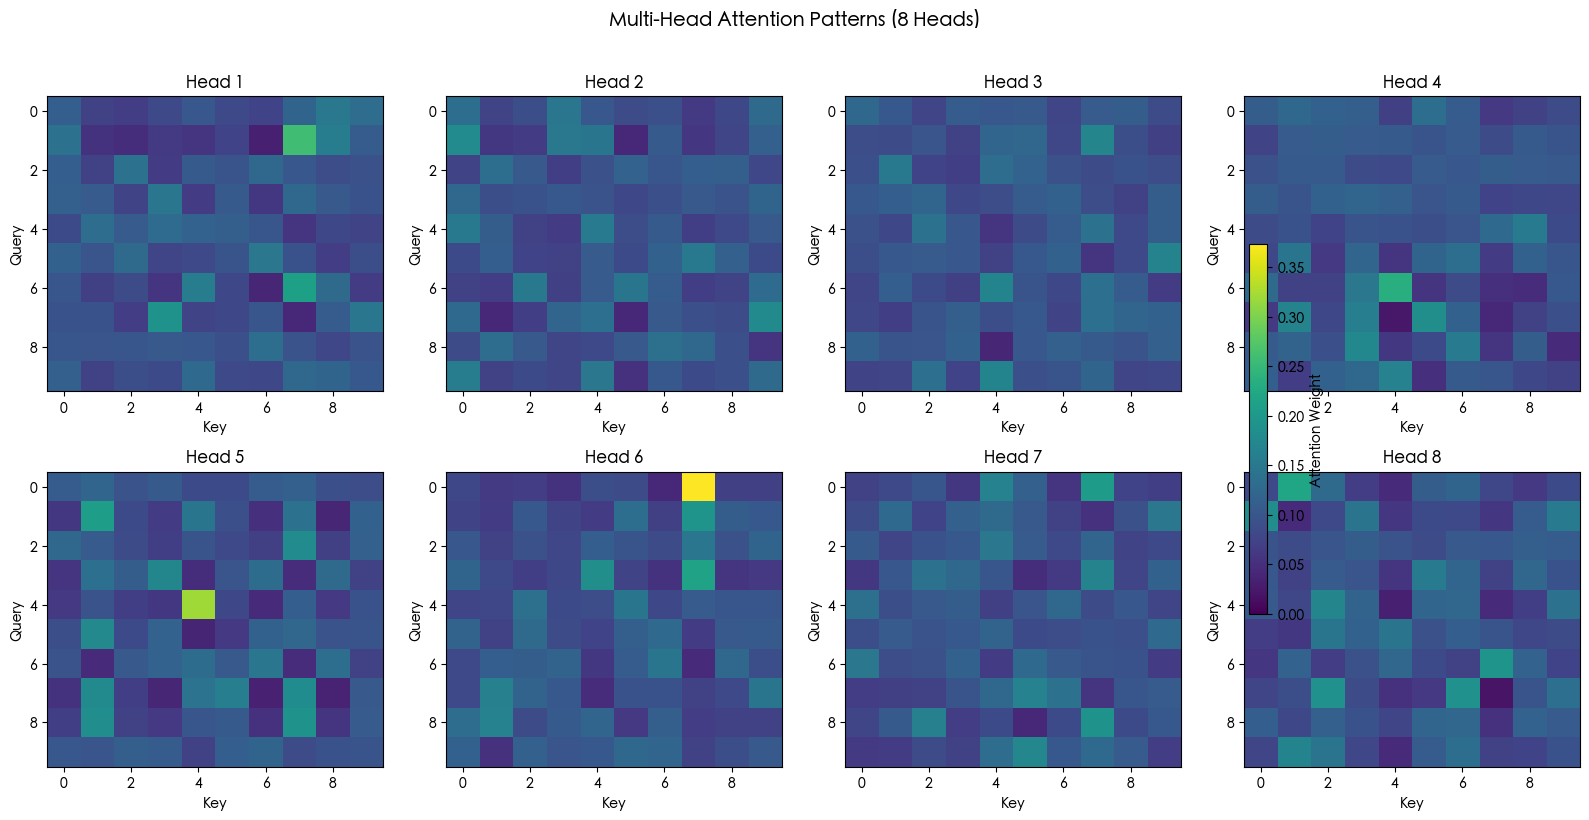

圖片已儲存：multi_head_attention.png

每個頭學習不同的注意力模式！


In [5]:
# 視覺化不同注意力頭的模式
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# 取第一個批次的注意力權重
weights = mha.attention_weights[0].detach().numpy()

for i, ax in enumerate(axes.flat):
    im = ax.imshow(weights[i], cmap='viridis', aspect='auto', vmin=0, vmax=weights.max())
    ax.set_title(f'Head {i+1}')
    ax.set_xlabel('Key')
    ax.set_ylabel('Query')

plt.suptitle('Multi-Head Attention Patterns (8 Heads)', fontsize=14, y=1.02)
fig.colorbar(im, ax=axes, label='Attention Weight', shrink=0.6)
plt.tight_layout()
plt.savefig('multi_head_attention.png', dpi=150, bbox_inches='tight')
plt.show()

print("圖片已儲存：multi_head_attention.png")
print("\n每個頭學習不同的注意力模式！")

## 3. 位置編碼

Transformer 沒有循環結構，需要明確加入位置資訊：

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

**特性**：
- 每個位置有唯一的編碼
- 可以表達相對位置關係
- 可以外推到更長的序列

In [6]:
class PositionalEncoding(nn.Module):
    """
    正弦波位置編碼
    
    使用不同頻率的正弦和餘弦函數編碼位置資訊
    """
    
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        """
        Args:
            d_model: 模型維度
            max_len: 最大序列長度
            dropout: Dropout 比例
        """
        super().__init__()
        
        self.dropout = nn.Dropout(dropout)
        
        # 建立位置編碼矩陣
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        
        # 計算除數項：10000^(2i/d_model)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        # 偶數位置用 sin，奇數位置用 cos
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # 加入批次維度：[max_len, d_model] -> [1, max_len, d_model]
        pe = pe.unsqueeze(0)
        
        # 註冊為 buffer（不是參數，但會隨模型儲存）
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        """
        Args:
            x: [batch, seq_len, d_model]
        
        Returns:
            [batch, seq_len, d_model]
        """
        # 加上位置編碼
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

# 測試位置編碼
d_model = 64
max_len = 100

pe_module = PositionalEncoding(d_model, max_len, dropout=0.0)

# 取出位置編碼矩陣
pe = pe_module.pe[0, :50, :].numpy()  # 取前 50 個位置

print("位置編碼：")
print(f"  編碼矩陣形狀: {pe.shape}")
print(f"  值範圍: [{pe.min():.4f}, {pe.max():.4f}]")

位置編碼：
  編碼矩陣形狀: (50, 64)
  值範圍: [-1.0000, 1.0000]


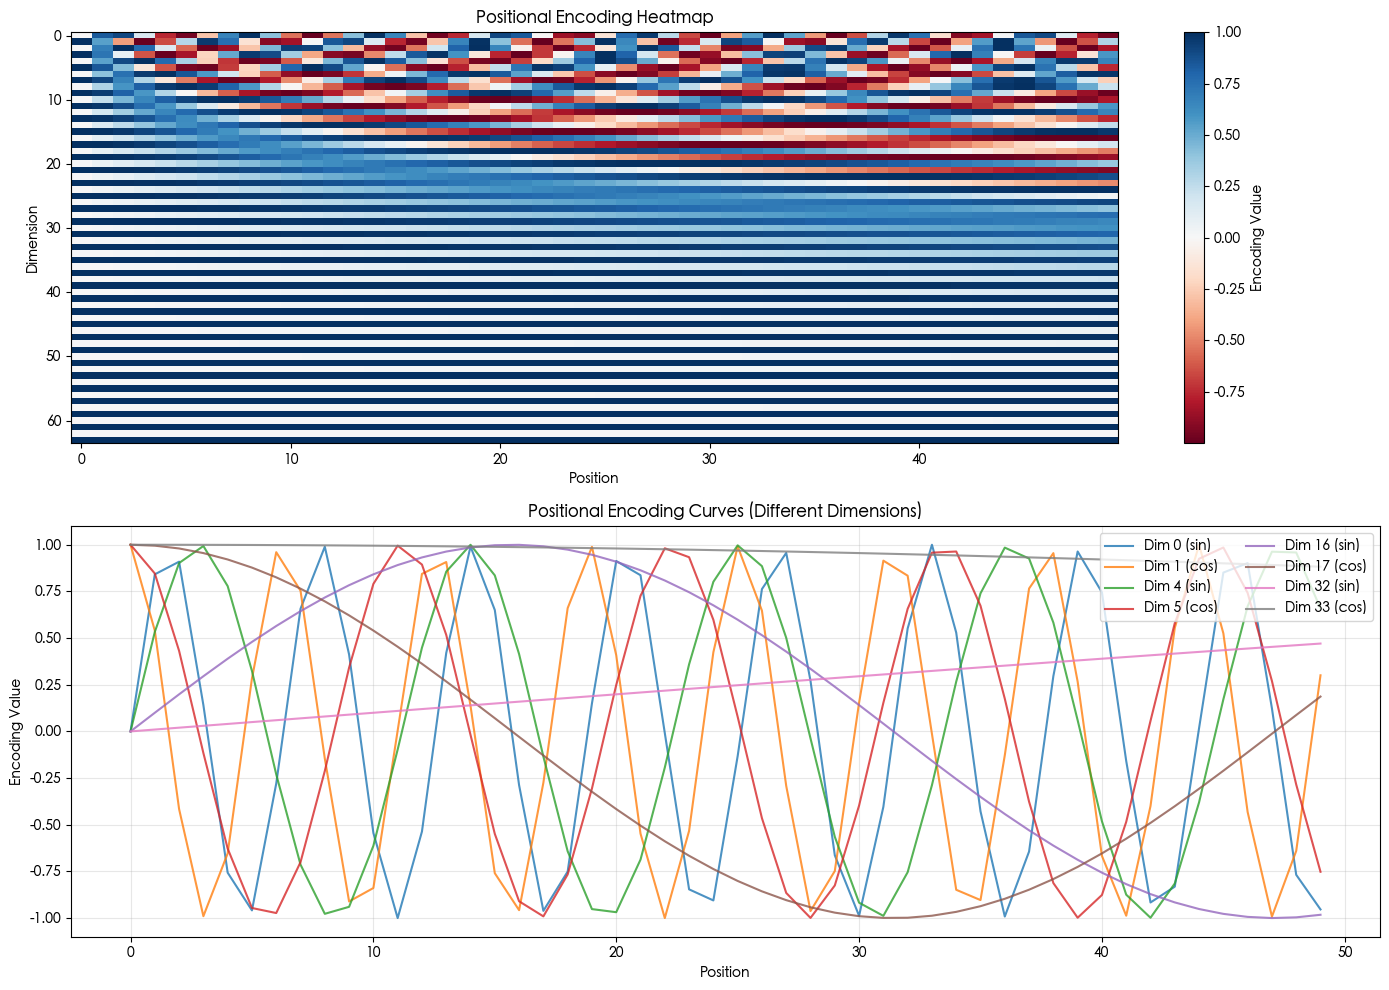

圖片已儲存：positional_encoding.png

低維度變化快（高頻），高維度變化慢（低頻）


In [7]:
# 視覺化位置編碼
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 位置編碼熱圖
ax1 = axes[0]
im = ax1.imshow(pe.T, cmap='RdBu', aspect='auto')
plt.colorbar(im, ax=ax1, label='Encoding Value')
ax1.set_xlabel('Position')
ax1.set_ylabel('Dimension')
ax1.set_title('Positional Encoding Heatmap')

# 不同維度的位置編碼曲線
ax2 = axes[1]
dims_to_plot = [0, 1, 4, 5, 16, 17, 32, 33]
for dim in dims_to_plot:
    label = f'Dim {dim} ({"sin" if dim % 2 == 0 else "cos"})'
    ax2.plot(pe[:, dim], label=label, alpha=0.8)

ax2.set_xlabel('Position')
ax2.set_ylabel('Encoding Value')
ax2.set_title('Positional Encoding Curves (Different Dimensions)')
ax2.legend(loc='upper right', ncol=2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('positional_encoding.png', dpi=150, bbox_inches='tight')
plt.show()

print("圖片已儲存：positional_encoding.png")
print("\n低維度變化快（高頻），高維度變化慢（低頻）")

## 4. 前饋網路 (Feed-Forward Network)

對每個位置獨立應用相同的前饋網路：

$$\text{FFN}(x) = \max(0, xW_1 + b_1)W_2 + b_2$$

通常隱藏層維度是模型維度的 4 倍（如 512 → 2048）

In [8]:
class FeedForward(nn.Module):
    """
    位置前饋網路
    
    兩層線性變換，中間夾 ReLU 活化函數
    """
    
    def __init__(self, d_model, d_ff, dropout=0.1):
        """
        Args:
            d_model: 模型維度
            d_ff: 前饋網路隱藏層維度（通常是 d_model 的 4 倍）
            dropout: Dropout 比例
        """
        super().__init__()
        
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        """
        Args:
            x: [batch, seq_len, d_model]
        
        Returns:
            [batch, seq_len, d_model]
        """
        # 第一層 + ReLU
        x = F.relu(self.linear1(x))
        x = self.dropout(x)
        
        # 第二層
        x = self.linear2(x)
        
        return x

# 測試前饋網路
d_model = 64
d_ff = 256  # 4 倍

ff = FeedForward(d_model, d_ff)
x = torch.randn(2, 10, d_model)
output = ff(x)

print("前饋網路測試：")
print(f"  輸入維度 d_model: {d_model}")
print(f"  隱藏層維度 d_ff: {d_ff}（{d_ff // d_model} 倍）")
print(f"  輸入形狀: {x.shape}")
print(f"  輸出形狀: {output.shape}")

前饋網路測試：
  輸入維度 d_model: 64
  隱藏層維度 d_ff: 256（4 倍）
  輸入形狀: torch.Size([2, 10, 64])
  輸出形狀: torch.Size([2, 10, 64])


## 5. 層正規化 (Layer Normalization)

對每個樣本在特徵維度上正規化：

$$\text{LayerNorm}(x) = \gamma \cdot \frac{x - \mu}{\sigma + \epsilon} + \beta$$

與 BatchNorm 不同，LayerNorm 不依賴批次大小，適合序列模型

In [9]:
# PyTorch 已有 LayerNorm，這裡示範手動實作
class ManualLayerNorm(nn.Module):
    """
    手動實作的層正規化（用於理解原理）
    """
    
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        
        # 可學習的縮放和偏移參數
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta = nn.Parameter(torch.zeros(d_model))
        self.eps = eps
    
    def forward(self, x):
        # 計算均值和標準差（在最後一個維度上）
        mean = x.mean(dim=-1, keepdim=True)
        std = x.std(dim=-1, keepdim=True)
        
        # 正規化
        normalized = (x - mean) / (std + self.eps)
        
        # 縮放和偏移
        output = self.gamma * normalized + self.beta
        
        return output

# 比較手動實作和 PyTorch 內建
d_model = 64
x = torch.randn(2, 10, d_model) * 5 + 3  # 有偏移的輸入

manual_ln = ManualLayerNorm(d_model)
pytorch_ln = nn.LayerNorm(d_model)

out_manual = manual_ln(x)
out_pytorch = pytorch_ln(x)

print("層正規化測試：")
print(f"  輸入均值: {x.mean():.4f}，標準差: {x.std():.4f}")
print(f"  手動實作輸出均值: {out_manual.mean():.4f}，標準差: {out_manual.std():.4f}")
print(f"  PyTorch 輸出均值: {out_pytorch.mean():.4f}，標準差: {out_pytorch.std():.4f}")

層正規化測試：
  輸入均值: 2.8870，標準差: 5.1878
  手動實作輸出均值: -0.0000，標準差: 0.9925
  PyTorch 輸出均值: -0.0000，標準差: 1.0004


## 6. 完整 Transformer 編碼器層

一個編碼器層包含：
1. 多頭自注意力 + 殘差連接 + 層正規化
2. 前饋網路 + 殘差連接 + 層正規化

In [10]:
class TransformerEncoderLayer(nn.Module):
    """
    Transformer 編碼器層
    
    包含多頭自注意力和前饋網路，帶殘差連接和層正規化
    """
    
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        """
        Args:
            d_model: 模型維度
            num_heads: 注意力頭數
            d_ff: 前饋網路隱藏層維度
            dropout: Dropout 比例
        """
        super().__init__()
        
        # 多頭自注意力
        self.self_attention = MultiHeadAttention(d_model, num_heads, dropout)
        
        # 前饋網路
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        
        # 層正規化
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        # Dropout
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, mask=None):
        """
        Args:
            x: [batch, seq_len, d_model]
            mask: 可選的遮罩
        
        Returns:
            [batch, seq_len, d_model]
        """
        # 自注意力 + 殘差連接 + 層正規化（Post-Norm）
        attn_output = self.self_attention(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        
        # 前饋網路 + 殘差連接 + 層正規化
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        
        return x

# 測試編碼器層
d_model = 64
num_heads = 8
d_ff = 256
batch_size = 2
seq_len = 10

encoder_layer = TransformerEncoderLayer(d_model, num_heads, d_ff)
x = torch.randn(batch_size, seq_len, d_model)
output = encoder_layer(x)

print("Transformer 編碼器層測試：")
print(f"  輸入形狀: {x.shape}")
print(f"  輸出形狀: {output.shape}")
print(f"\n層結構：")
print(f"  1. 多頭自注意力（{num_heads} 頭）")
print(f"  2. 殘差連接 + 層正規化")
print(f"  3. 前饋網路（{d_model} → {d_ff} → {d_model}）")
print(f"  4. 殘差連接 + 層正規化")

Transformer 編碼器層測試：
  輸入形狀: torch.Size([2, 10, 64])
  輸出形狀: torch.Size([2, 10, 64])

層結構：
  1. 多頭自注意力（8 頭）
  2. 殘差連接 + 層正規化
  3. 前饋網路（64 → 256 → 64）
  4. 殘差連接 + 層正規化


## 7. 因果遮罩（Causal Mask）

對於自回歸模型（如 GPT），需要遮罩阻止注意力看到未來的位置

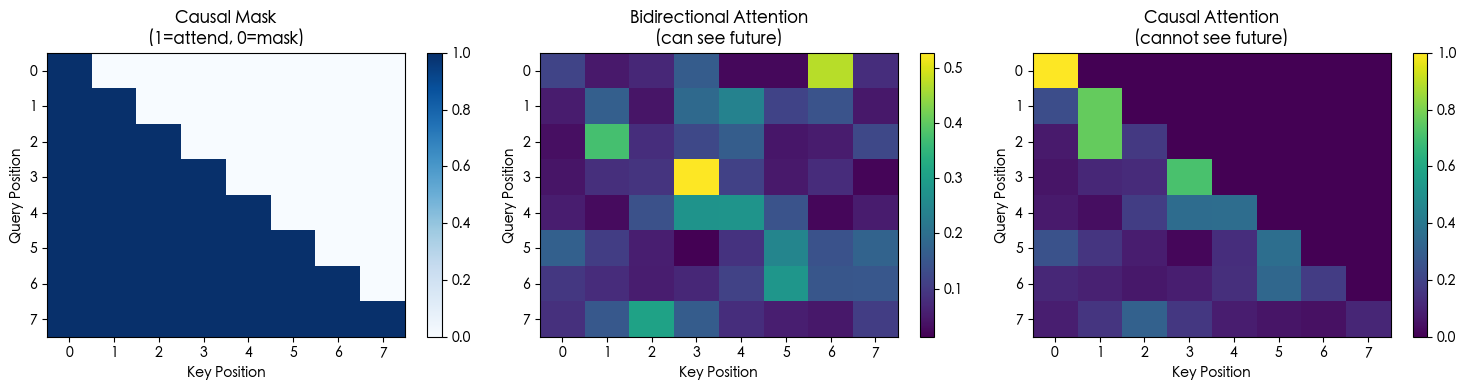

圖片已儲存：causal_mask.png

因果遮罩確保每個位置只能關注自己和之前的位置


In [11]:
def create_causal_mask(seq_len):
    """
    建立因果遮罩
    
    下三角矩陣，阻止注意力關注未來位置
    
    Args:
        seq_len: 序列長度
    
    Returns:
        mask: [1, 1, seq_len, seq_len]
    """
    # 建立下三角遮罩（1 表示可以關注，0 表示遮罩）
    mask = torch.tril(torch.ones(seq_len, seq_len))
    return mask.unsqueeze(0).unsqueeze(0)

# 視覺化因果遮罩和注意力
seq_len = 8
d_model = 64

# 建立遮罩
causal_mask = create_causal_mask(seq_len)

# 測試有無遮罩的注意力
Q = torch.randn(1, 1, seq_len, d_model // 8)
K = torch.randn(1, 1, seq_len, d_model // 8)
V = torch.randn(1, 1, seq_len, d_model // 8)

# 無遮罩（雙向）
_, attn_bidirectional = scaled_dot_product_attention(Q, K, V, mask=None)

# 有遮罩（因果）
_, attn_causal = scaled_dot_product_attention(Q, K, V, mask=causal_mask)

# 視覺化
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 因果遮罩
ax1 = axes[0]
im1 = ax1.imshow(causal_mask[0, 0].numpy(), cmap='Blues', aspect='auto')
ax1.set_title('Causal Mask\n(1=attend, 0=mask)')
ax1.set_xlabel('Key Position')
ax1.set_ylabel('Query Position')
plt.colorbar(im1, ax=ax1)

# 雙向注意力
ax2 = axes[1]
im2 = ax2.imshow(attn_bidirectional[0, 0].detach().numpy(), cmap='viridis', aspect='auto')
ax2.set_title('Bidirectional Attention\n(can see future)')
ax2.set_xlabel('Key Position')
ax2.set_ylabel('Query Position')
plt.colorbar(im2, ax=ax2)

# 因果注意力
ax3 = axes[2]
im3 = ax3.imshow(attn_causal[0, 0].detach().numpy(), cmap='viridis', aspect='auto')
ax3.set_title('Causal Attention\n(cannot see future)')
ax3.set_xlabel('Key Position')
ax3.set_ylabel('Query Position')
plt.colorbar(im3, ax=ax3)

plt.tight_layout()
plt.savefig('causal_mask.png', dpi=150, bbox_inches='tight')
plt.show()

print("圖片已儲存：causal_mask.png")
print("\n因果遮罩確保每個位置只能關注自己和之前的位置")

## 8. 完整 Transformer 編碼器

堆疊多個編碼器層，加上嵌入和位置編碼

In [12]:
class TransformerEncoder(nn.Module):
    """
    完整的 Transformer 編碼器
    
    包含詞嵌入、位置編碼和多個編碼器層
    """
    
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers,
                 max_len=5000, dropout=0.1):
        """
        Args:
            vocab_size: 詞彙表大小
            d_model: 模型維度
            num_heads: 注意力頭數
            d_ff: 前饋網路隱藏層維度
            num_layers: 編碼器層數
            max_len: 最大序列長度
            dropout: Dropout 比例
        """
        super().__init__()
        
        # 詞嵌入
        self.embedding = nn.Embedding(vocab_size, d_model)
        
        # 位置編碼
        self.positional_encoding = PositionalEncoding(d_model, max_len, dropout)
        
        # 編碼器層堆疊
        self.layers = nn.ModuleList([
            TransformerEncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        
        # 縮放因子（嵌入層的輸出需要縮放）
        self.d_model = d_model
    
    def forward(self, x, mask=None):
        """
        Args:
            x: [batch, seq_len] 輸入 token 索引
            mask: 可選的遮罩
        
        Returns:
            [batch, seq_len, d_model]
        """
        # 嵌入 + 縮放
        x = self.embedding(x) * math.sqrt(self.d_model)
        
        # 加上位置編碼
        x = self.positional_encoding(x)
        
        # 通過所有編碼器層
        for layer in self.layers:
            x = layer(x, mask)
        
        return x

# 測試完整編碼器
vocab_size = 10000
d_model = 64
num_heads = 8
d_ff = 256
num_layers = 6
batch_size = 2
seq_len = 20

encoder = TransformerEncoder(vocab_size, d_model, num_heads, d_ff, num_layers)

# 隨機輸入 token
input_tokens = torch.randint(0, vocab_size, (batch_size, seq_len))
output = encoder(input_tokens)

print("Transformer 編碼器測試：")
print(f"  詞彙表大小: {vocab_size}")
print(f"  模型維度 d_model: {d_model}")
print(f"  注意力頭數: {num_heads}")
print(f"  前饋網路維度 d_ff: {d_ff}")
print(f"  編碼器層數: {num_layers}")
print(f"  輸入形狀: {input_tokens.shape}")
print(f"  輸出形狀: {output.shape}")

# 計算參數量
total_params = sum(p.numel() for p in encoder.parameters())
print(f"\n總參數量: {total_params:,}")

Transformer 編碼器測試：
  詞彙表大小: 10000
  模型維度 d_model: 64
  注意力頭數: 8
  前饋網路維度 d_ff: 256
  編碼器層數: 6
  輸入形狀: torch.Size([2, 20])
  輸出形狀: torch.Size([2, 20, 64])

總參數量: 939,904


## 9. Transformer 解碼器層

解碼器層比編碼器多一個交叉注意力（Cross-Attention）子層

In [13]:
class TransformerDecoderLayer(nn.Module):
    """
    Transformer 解碼器層
    
    包含：
    1. 遮罩自注意力（防止看到未來）
    2. 交叉注意力（關注編碼器輸出）
    3. 前饋網路
    """
    
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        
        # 遮罩自注意力
        self.self_attention = MultiHeadAttention(d_model, num_heads, dropout)
        
        # 交叉注意力（編碼器-解碼器注意力）
        self.cross_attention = MultiHeadAttention(d_model, num_heads, dropout)
        
        # 前饋網路
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        
        # 層正規化
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, encoder_output, src_mask=None, tgt_mask=None):
        """
        Args:
            x: 解碼器輸入 [batch, tgt_len, d_model]
            encoder_output: 編碼器輸出 [batch, src_len, d_model]
            src_mask: 來源遮罩（用於交叉注意力）
            tgt_mask: 目標遮罩（因果遮罩）
        """
        # 遮罩自注意力
        self_attn_output = self.self_attention(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(self_attn_output))
        
        # 交叉注意力：Q 來自解碼器，K、V 來自編碼器
        cross_attn_output = self.cross_attention(x, encoder_output, encoder_output, src_mask)
        x = self.norm2(x + self.dropout(cross_attn_output))
        
        # 前饋網路
        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout(ff_output))
        
        return x

# 測試解碼器層
d_model = 64
num_heads = 8
d_ff = 256
batch_size = 2
src_len = 15  # 來源序列長度
tgt_len = 10  # 目標序列長度

decoder_layer = TransformerDecoderLayer(d_model, num_heads, d_ff)

# 模擬輸入
decoder_input = torch.randn(batch_size, tgt_len, d_model)
encoder_output = torch.randn(batch_size, src_len, d_model)

# 建立因果遮罩
tgt_mask = create_causal_mask(tgt_len)

output = decoder_layer(decoder_input, encoder_output, tgt_mask=tgt_mask)

print("Transformer 解碼器層測試：")
print(f"  解碼器輸入形狀: {decoder_input.shape}")
print(f"  編碼器輸出形狀: {encoder_output.shape}")
print(f"  解碼器輸出形狀: {output.shape}")
print(f"\n解碼器層包含：")
print(f"  1. 遮罩自注意力（關注自己和之前的位置）")
print(f"  2. 交叉注意力（關注編碼器輸出）")
print(f"  3. 前饋網路")

Transformer 解碼器層測試：
  解碼器輸入形狀: torch.Size([2, 10, 64])
  編碼器輸出形狀: torch.Size([2, 15, 64])
  解碼器輸出形狀: torch.Size([2, 10, 64])

解碼器層包含：
  1. 遮罩自注意力（關注自己和之前的位置）
  2. 交叉注意力（關注編碼器輸出）
  3. 前饋網路


## 10. 視覺化：為什麼要縮放？

展示不縮放時 softmax 的問題

/var/folders/4z/9g413kps2l14p9j7pzv9kp8c0000gn/T/ipykernel_45545/3727910706.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


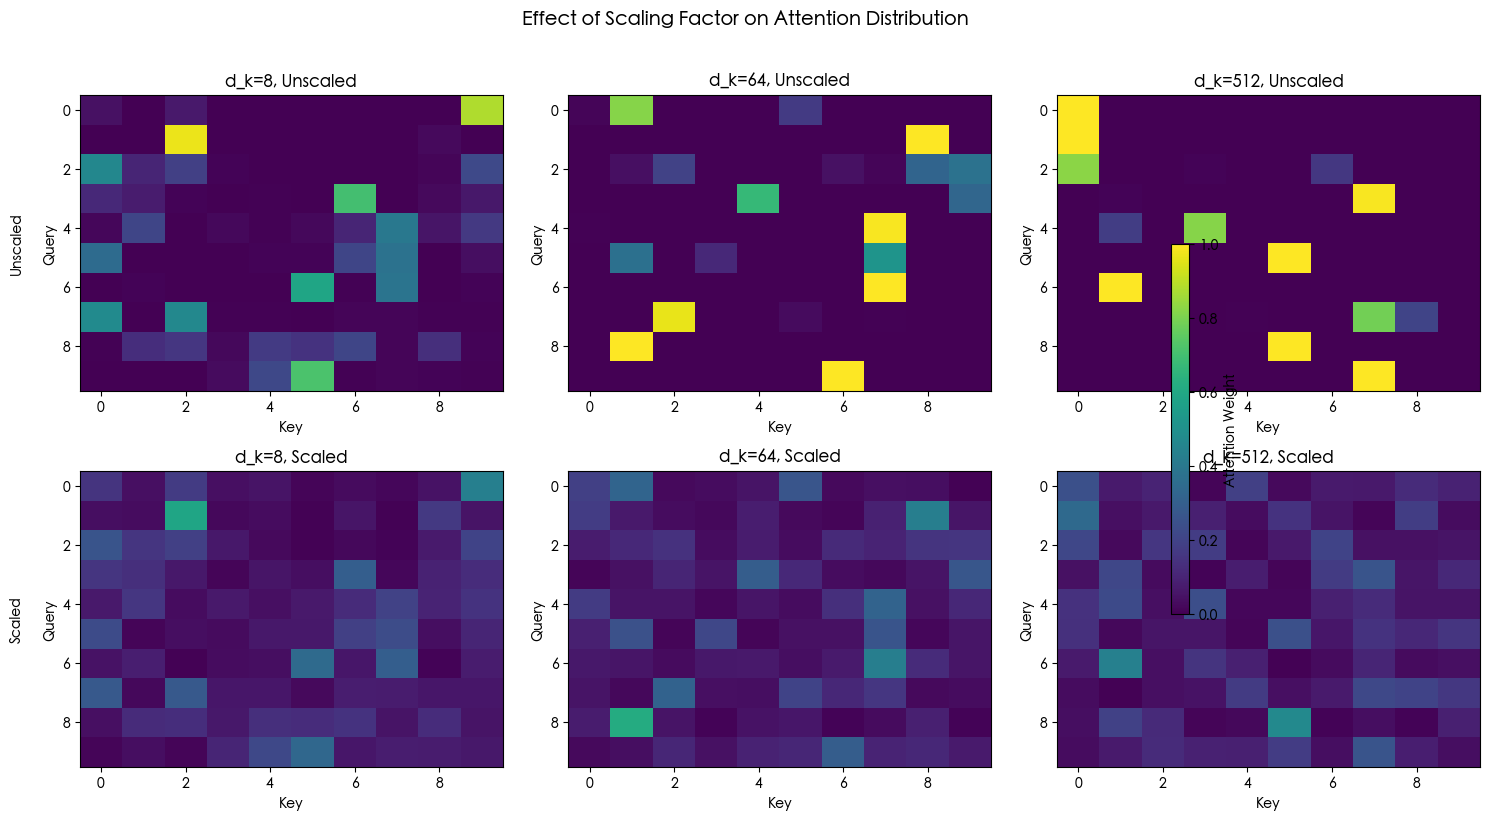

圖片已儲存：scaling_effect.png

當 d_k 較大時：
  - 未縮放：softmax 輸出接近 one-hot（梯度消失）
  - 縮放後：softmax 輸出較為平滑（梯度穩定）


In [14]:
# 展示縮放的重要性
def visualize_scaling_effect():
    """視覺化縮放因子對 softmax 的影響"""
    
    d_k_values = [8, 64, 512]  # 不同的維度
    
    fig, axes = plt.subplots(2, len(d_k_values), figsize=(15, 8))
    
    for i, d_k in enumerate(d_k_values):
        # 生成隨機 Q 和 K
        Q = torch.randn(1, 1, 10, d_k)
        K = torch.randn(1, 1, 10, d_k)
        
        # 未縮放的分數
        scores_unscaled = torch.matmul(Q, K.transpose(-2, -1))
        
        # 縮放後的分數
        scores_scaled = scores_unscaled / math.sqrt(d_k)
        
        # Softmax
        attn_unscaled = F.softmax(scores_unscaled, dim=-1)
        attn_scaled = F.softmax(scores_scaled, dim=-1)
        
        # 繪製未縮放
        im1 = axes[0, i].imshow(attn_unscaled[0, 0].detach().numpy(), 
                                 cmap='viridis', aspect='auto', vmin=0, vmax=1)
        axes[0, i].set_title(f'd_k={d_k}, Unscaled')
        axes[0, i].set_xlabel('Key')
        axes[0, i].set_ylabel('Query')
        
        # 繪製縮放後
        im2 = axes[1, i].imshow(attn_scaled[0, 0].detach().numpy(), 
                                 cmap='viridis', aspect='auto', vmin=0, vmax=1)
        axes[1, i].set_title(f'd_k={d_k}, Scaled')
        axes[1, i].set_xlabel('Key')
        axes[1, i].set_ylabel('Query')
    
    axes[0, 0].set_ylabel('Unscaled\n\nQuery')
    axes[1, 0].set_ylabel('Scaled\n\nQuery')
    
    fig.colorbar(im2, ax=axes, label='Attention Weight', shrink=0.6)
    plt.suptitle('Effect of Scaling Factor on Attention Distribution', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('scaling_effect.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("圖片已儲存：scaling_effect.png")
    print("\n當 d_k 較大時：")
    print("  - 未縮放：softmax 輸出接近 one-hot（梯度消失）")
    print("  - 縮放後：softmax 輸出較為平滑（梯度穩定）")

visualize_scaling_effect()

## 11. 簡單文本生成示範

使用 Decoder-only 架構進行簡單的下一字元預測

In [15]:
class MiniGPT(nn.Module):
    """
    迷你 GPT 模型
    
    Decoder-only 架構，用於字元級語言模型
    """
    
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers, max_len=512):
        super().__init__()
        
        # 詞嵌入
        self.embedding = nn.Embedding(vocab_size, d_model)
        
        # 位置編碼
        self.positional_encoding = PositionalEncoding(d_model, max_len, dropout=0.1)
        
        # Decoder 層（使用編碼器層 + 因果遮罩）
        self.layers = nn.ModuleList([
            TransformerEncoderLayer(d_model, num_heads, d_ff, dropout=0.1)
            for _ in range(num_layers)
        ])
        
        # 輸出投影
        self.output_projection = nn.Linear(d_model, vocab_size)
        
        self.d_model = d_model
    
    def forward(self, x):
        """
        Args:
            x: [batch, seq_len] 輸入 token 索引
        
        Returns:
            logits: [batch, seq_len, vocab_size]
        """
        seq_len = x.shape[1]
        
        # 建立因果遮罩
        causal_mask = create_causal_mask(seq_len).to(x.device)
        
        # 嵌入 + 位置編碼
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.positional_encoding(x)
        
        # 通過所有層
        for layer in self.layers:
            x = layer(x, causal_mask)
        
        # 輸出 logits
        logits = self.output_projection(x)
        
        return logits
    
    @torch.no_grad()
    def generate(self, start_tokens, max_new_tokens, temperature=1.0):
        """
        自回歸生成
        
        Args:
            start_tokens: [1, seq_len] 起始 token
            max_new_tokens: 要生成的新 token 數
            temperature: 溫度參數（越高越隨機）
        """
        self.eval()
        tokens = start_tokens.clone()
        
        for _ in range(max_new_tokens):
            # 前向傳播
            logits = self(tokens)
            
            # 只取最後一個位置的 logits
            next_logits = logits[:, -1, :] / temperature
            
            # 取樣下一個 token
            probs = F.softmax(next_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            
            # 加到序列後面
            tokens = torch.cat([tokens, next_token], dim=1)
        
        return tokens

# 建立迷你 GPT
vocab_size = 128  # ASCII 字元
d_model = 64
num_heads = 4
d_ff = 256
num_layers = 2

mini_gpt = MiniGPT(vocab_size, d_model, num_heads, d_ff, num_layers)

print("迷你 GPT 模型：")
print(f"  詞彙表大小: {vocab_size}")
print(f"  模型維度: {d_model}")
print(f"  層數: {num_layers}")

# 計算參數量
total_params = sum(p.numel() for p in mini_gpt.parameters())
print(f"  總參數量: {total_params:,}")

# 測試生成
start_text = "Hello"
start_tokens = torch.tensor([[ord(c) for c in start_text]])

generated = mini_gpt.generate(start_tokens, max_new_tokens=20, temperature=1.0)
generated_text = ''.join([chr(min(127, max(0, t))) for t in generated[0].tolist()])

print(f"\n生成測試（未訓練模型，輸出是隨機的）：")
print(f"  起始文字: '{start_text}'")
print(f"  生成結果: '{generated_text}'")

迷你 GPT 模型：
  詞彙表大小: 128
  模型維度: 64
  層數: 2
  總參數量: 116,480

生成測試（未訓練模型，輸出是隨機的）：
  起始文字: 'Hello'
qs3f_6OV1|Q6\N
'


## 12. 架構比較圖

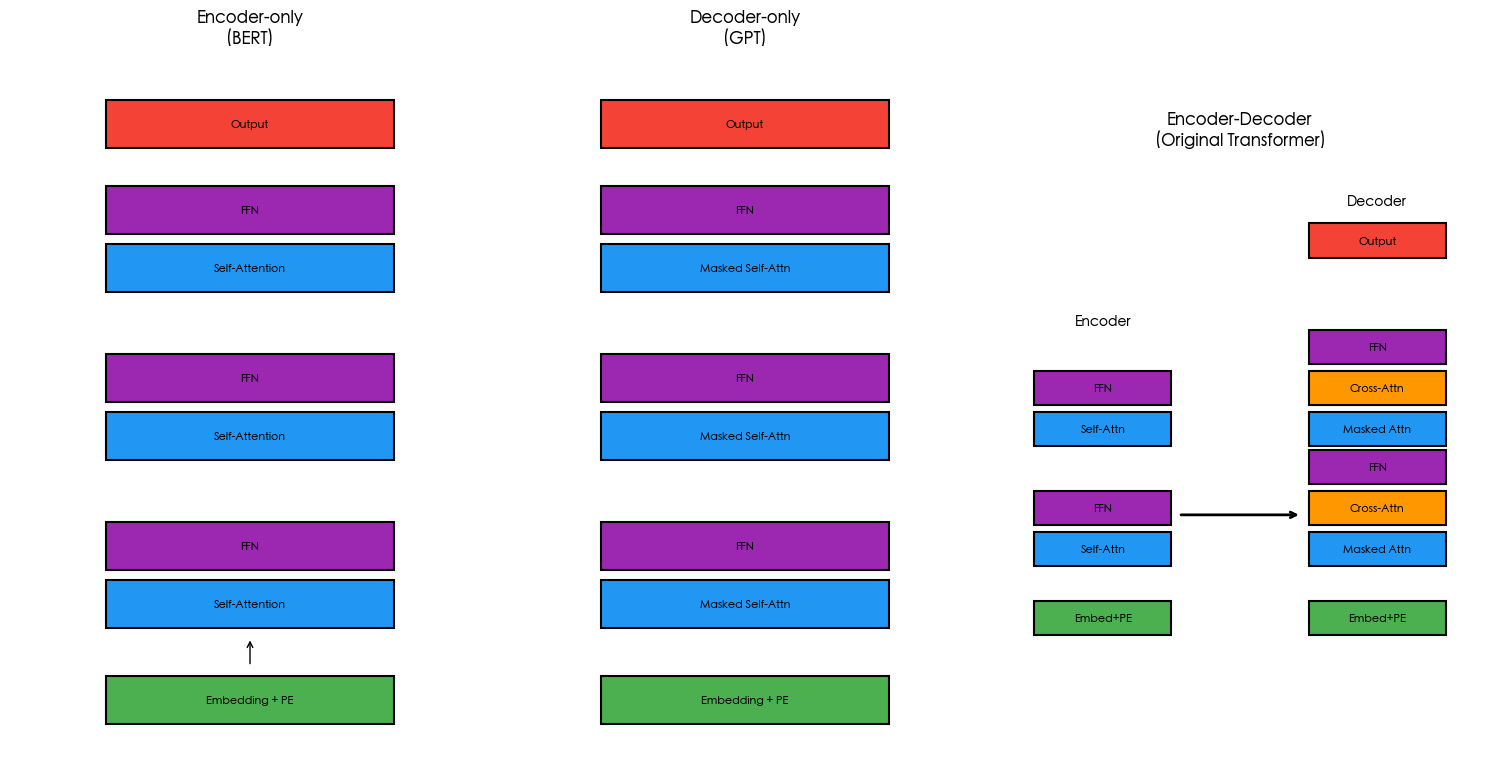

圖片已儲存：transformer_variants.png


In [16]:
# 繪製架構比較圖
fig, axes = plt.subplots(1, 3, figsize=(15, 8))

# 顏色定義
colors = {
    'embedding': '#4CAF50',
    'self_attn': '#2196F3',
    'cross_attn': '#FF9800',
    'ffn': '#9C27B0',
    'norm': '#607D8B',
    'output': '#F44336'
}

def draw_block(ax, x, y, w, h, color, text):
    """繪製一個區塊"""
    rect = plt.Rectangle((x, y), w, h, facecolor=color, edgecolor='black', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=8, fontweight='bold')

# Encoder-only (BERT)
ax1 = axes[0]
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 15)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title('Encoder-only\n(BERT)', fontsize=12, fontweight='bold')

draw_block(ax1, 2, 1, 6, 1, colors['embedding'], 'Embedding + PE')
for i in range(3):
    y = 3 + i * 3.5
    draw_block(ax1, 2, y, 6, 1, colors['self_attn'], 'Self-Attention')
    draw_block(ax1, 2, y + 1.2, 6, 1, colors['ffn'], 'FFN')
draw_block(ax1, 2, 13, 6, 1, colors['output'], 'Output')
ax1.annotate('', xy=(5, 2.8), xytext=(5, 2.2), arrowprops=dict(arrowstyle='->', color='black'))

# Decoder-only (GPT)
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 15)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title('Decoder-only\n(GPT)', fontsize=12, fontweight='bold')

draw_block(ax2, 2, 1, 6, 1, colors['embedding'], 'Embedding + PE')
for i in range(3):
    y = 3 + i * 3.5
    draw_block(ax2, 2, y, 6, 1, colors['self_attn'], 'Masked Self-Attn')
    draw_block(ax2, 2, y + 1.2, 6, 1, colors['ffn'], 'FFN')
draw_block(ax2, 2, 13, 6, 1, colors['output'], 'Output')

# Encoder-Decoder (Original Transformer)
ax3 = axes[2]
ax3.set_xlim(0, 14)
ax3.set_ylim(0, 15)
ax3.set_aspect('equal')
ax3.axis('off')
ax3.set_title('Encoder-Decoder\n(Original Transformer)', fontsize=12, fontweight='bold')

# Encoder side
draw_block(ax3, 1, 1, 4, 1, colors['embedding'], 'Embed+PE')
for i in range(2):
    y = 3 + i * 3.5
    draw_block(ax3, 1, y, 4, 1, colors['self_attn'], 'Self-Attn')
    draw_block(ax3, 1, y + 1.2, 4, 1, colors['ffn'], 'FFN')

# Decoder side
draw_block(ax3, 9, 1, 4, 1, colors['embedding'], 'Embed+PE')
for i in range(2):
    y = 3 + i * 3.5
    draw_block(ax3, 9, y, 4, 1, colors['self_attn'], 'Masked Attn')
    draw_block(ax3, 9, y + 1.2, 4, 1, colors['cross_attn'], 'Cross-Attn')
    draw_block(ax3, 9, y + 2.4, 4, 1, colors['ffn'], 'FFN')
draw_block(ax3, 9, 12, 4, 1, colors['output'], 'Output')

# Cross-attention arrow
ax3.annotate('', xy=(8.8, 4.5), xytext=(5.2, 4.5), 
             arrowprops=dict(arrowstyle='->', color='black', lw=2))

# Labels
ax3.text(3, 10, 'Encoder', ha='center', fontsize=10, fontstyle='italic')
ax3.text(11, 13.5, 'Decoder', ha='center', fontsize=10, fontstyle='italic')

plt.tight_layout()
plt.savefig('transformer_variants.png', dpi=150, bbox_inches='tight')
plt.show()

print("圖片已儲存：transformer_variants.png")

## 總結

### 核心組件

1. **縮放點積注意力**：$\text{softmax}(QK^T/\sqrt{d_k})V$
2. **多頭注意力**：多個注意力頭關注不同子空間
3. **位置編碼**：用正弦/餘弦函數編碼位置資訊
4. **前饋網路**：每個位置獨立的兩層 MLP
5. **層正規化**：穩定訓練
6. **殘差連接**：幫助梯度流動

### 架構變體

| 架構 | 代表模型 | 適用任務 |
|------|---------|--------|
| Encoder-only | BERT | 理解任務（分類、問答）|
| Decoder-only | GPT | 生成任務（文本生成）|
| Encoder-Decoder | T5, BART | 序列到序列（翻譯、摘要）|

### 關鍵設計決策

- **縮放因子**：防止大維度時梯度消失
- **因果遮罩**：確保自回歸特性
- **Pre-Norm vs Post-Norm**：現代模型傾向 Pre-Norm

In [17]:
print("="*60)
print("第十三章：Transformer 實作完成！")
print("="*60)
print("\n本章實作了：")
print("  1. 縮放點積注意力（Scaled Dot-Product Attention）")
print("  2. 多頭注意力（Multi-Head Attention）")
print("  3. 位置編碼（Positional Encoding）")
print("  4. 前饋網路（Feed-Forward Network）")
print("  5. 層正規化（Layer Normalization）")
print("  6. 完整編碼器層和解碼器層")
print("  7. 因果遮罩（Causal Mask）")
print("  8. 迷你 GPT 模型")
print("\n生成的圖片：")
print("  - attention_weights.png：注意力權重視覺化")
print("  - multi_head_attention.png：多頭注意力模式")
print("  - positional_encoding.png：位置編碼視覺化")
print("  - causal_mask.png：因果遮罩效果")
print("  - scaling_effect.png：縮放因子的重要性")
print("  - transformer_variants.png：三種架構變體")

第十三章：Transformer 實作完成！

本章實作了：
  1. 縮放點積注意力（Scaled Dot-Product Attention）
  2. 多頭注意力（Multi-Head Attention）
  3. 位置編碼（Positional Encoding）
  4. 前饋網路（Feed-Forward Network）
  5. 層正規化（Layer Normalization）
  6. 完整編碼器層和解碼器層
  7. 因果遮罩（Causal Mask）
  8. 迷你 GPT 模型

生成的圖片：
  - attention_weights.png：注意力權重視覺化
  - multi_head_attention.png：多頭注意力模式
  - positional_encoding.png：位置編碼視覺化
  - causal_mask.png：因果遮罩效果
  - scaling_effect.png：縮放因子的重要性
  - transformer_variants.png：三種架構變體
